# Consistency benchmarks

Quantifying consistency of implemented protocols in terms of dirty reads, synchrony violations, latency and throughput.

Benchmark used: YCSB A, B, high_contention

MONSTER protocol params:

- round_time
- read_retries
- read_offset

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## YCSB A

In [16]:

async_best_effort = [
    {
        "read_retries": 0,
        "dr_percent": 12184 / 10003905,
        "read_avg": 1070, "read_p99": 1620, "read_p9999": 5100, "read_p100": 12074166,
        "write_avg": 1010, "write_p99": 1370, "write_p999": 4900, "write_p100": 12434906,
        "tput": 881246,
    },
    {
        "read_retries": 1,
        "dr_percent": 796 / 10010651,
        "read_avg": 1070, "read_p99": 1640, "read_p9999": 4700, "read_p100": 12410000,
        "write_avg": 1010, "write_p99": 1340, "write_p999": 4520, "write_p100": 11910000,
        "tput": 881191,
    },
    {
        "read_retries": 10,
        "dr_percent": 341 / 10010651,
        "read_avg": 1080, "read_p99": 1640, "read_p9999": 5350, "read_p100": 11950000,
        "write_avg": 1010, "write_p99": 1330, "write_p999": 4650, "write_p100": 11910000,
        "tput": 878767,
    },
    {
        "read_retries": 100,
        "dr_percent": 212 / 10010651,
        "read_avg": 1080, "read_p99": 1640, "read_p9999": 8060, "read_p100": 11840000,
        "write_avg": 1010, "write_p99": 1330, "write_p999": 4650, "write_p100": 11970000,
        "tput": 876984,
    },
    {
        "read_retries": 1000,
        "dr_percent": 165 / 10010651,
        "read_avg": 1140, "read_p99": 1640, "read_p9999": 8820, "read_p100": 12000000,
        "write_avg": 1010, "write_p99": 1330, "write_p999": 4650, "write_p100": 11970000,
        "tput": 852616,
    },
    {
        "read_retries": 10000,
        "dr_percent": 131 / 10003905,
        "read_avg": 1660, "read_p99": 1630, "read_p9999": 7350, "read_p100": 23000000,
        "write_avg": 1010, "write_p99": 1330, "write_p999": 4650, "write_p100": 11970000,
        "tput": 852616,
    },
]


######################## monster
monster1us = [
    {
        "read_retries": 0,
        "dr_percent": 4889 / 10003905,
        "read_avg": 1060, "read_p99": 1570, "read_p9999": 6080, "read_p100": 10994166,
        "write_avg": 4030, "write_p99": 5100, "write_p999": 8590, "write_p100": 11334906,
        "tput": 378281,
    },
    {
        "read_retries": 1,
        "dr_percent": 1 / 10010651,
        "read_avg": 1060, "read_p99": 1590, "read_p9999": 5390, "read_p100": 12410000,
        "write_avg": 1010, "write_p99": 1340, "write_p999": 4520, "write_p100": 11910000,
        "tput": 378325,
    },
    {
        "read_retries": 10,
        "dr_percent": 1 / 10010651,
        "read_avg": 1050, "read_p99": 1570, "read_p9999": 4420, "read_p100": 11590000,
        "write_avg": 4040, "write_p99": 5040, "write_p999": 10400, "write_p100": 11760000,
        "tput": 376637,
    },
    {
        "read_retries": 100,
        "dr_percent": 0 / 10010651,
        "read_avg": 1070, "read_p99": 1590, "read_p9999": 4340, "read_p100": 11400000,
        "write_avg": 4040, "write_p99": 5015, "write_p999": 11400, "write_p100": 11660000,
        "tput": 376732,
    },
]

monster50ns = [
    {
        "read_retries": 10,
        "dr_percent": 2 / 10010651,
        "read_avg": 1060, "read_p99": 1570, "read_p9999": 4450, "read_p100": 11410000,
        "write_avg": 2970, "write_p99": 3440, "write_p999": 7030, "write_p100": 11260000,
        "tput": 472898,
    },
    {
        "read_retries": 100,
        "dr_percent": 3 / 10010651,
        "read_avg": 1060, "read_p99": 1580, "read_p9999": 5550, "read_p100": 11520000,
        "write_avg": 2980, "write_p99": 3460, "write_p999": 8290, "write_p100": 11860000,
        "tput": 471805,
    },
]

In [17]:
df = pd.DataFrame(async_best_effort)
df["label"] = "abe"
dfm = pd.DataFrame(monster1us)
dfm["label"] = "monster"
df = pd.concat([df, dfm])

dfm = pd.DataFrame(monster50ns)
dfm["label"] = "monster_async"
df = pd.concat([df, dfm])

In [18]:
df

,read_retries,dr_percent,read_avg,read_p99,read_p9999,read_p100,write_avg,write_p99,write_p999,write_p100,tput,label
0,0,1.217924e-03,1070,1620,5100,12074166,1010,1370,4900,12434906,881246,abe
1,1,7.951531e-05,1070,1640,4700,12410000,1010,1340,4520,11910000,881191,abe
2,10,3.406372e-05,1080,1640,5350,11950000,1010,1330,4650,11910000,878767,abe
3,100,2.117744e-05,1080,1640,8060,11840000,1010,1330,4650,11970000,876984,abe
4,1000,1.648244e-05,1140,1640,8820,12000000,1010,1330,4650,11970000,852616,abe
5,10000,1.309489e-05,1660,1630,7350,23000000,1010,1330,4650,11970000,852616,abe
0,0,4.887092e-04,1060,1570,6080,10994166,4030,5100,8590,11334906,378281,monster
1,1,9.989360e-08,1060,1590,5390,12410000,1010,1340,4520,11910000,378325,monster
2,10,9.989360e-08,1050,1570,4420,11590000,4040,5040,10400,11760000,376637,monster
3,100,0.000000e+00,1070,1590,4340,11400000,4040,5015,11400,11660000,376732,monster


<Axes: xlabel='read_retries'>

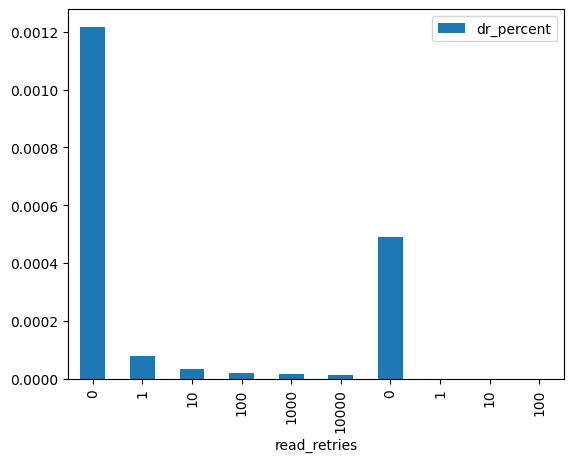

In [13]:
# fig, ax = plt.subplots()
df.plot(x="read_retries", y=["dr_percent"], kind="bar")

## YCSB A single key

In [ ]:
abe = [
    {
        "read_retries": 0,
        "dr_percent": 12184 / 10003905,
        "read_avg": 1070, "read_p99": 1620, "read_p9999": 5100, "read_p100": 12074166,
        "write_avg": 1010, "write_p99": 1370, "write_p999": 4900, "write_p100": 12434906,
        "tput": 881246,
    },
]